# Preprocessing et entraînement (Machine Learning)
*(Prédiction du **Physical experience level notation**)*

- **Dataset Kaggle** :  
  [Life Style Data – Kaggle](https://www.kaggle.com/datasets/jockeroika/life-style-data)

- **Transformation .csv > .db*** :  
  [Exploration des données - v1.5.pdf (voir section 2.2)](https://drive.google.com/file/d/1RDXAsx1oCIJUtfKLF3zpQefs7rojUSO3/view?usp=drive_link)

- **Source locale** :  
  `life_style_data_val.db`


## Import des librairies

In [128]:
# Standard library
from pathlib import Path
from datetime import datetime
import json
import yaml
import sqlite3
import shap
import joblib
import duckdb

# Data manipulation, visualization and statistics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import randint, uniform
from itables import show

# Scikit-learn
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
)
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
)
from sklearn.ensemble import (
    RandomForestRegressor,
    BaggingRegressor,
    GradientBoostingRegressor,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

## Variables globales

In [129]:
# Le notebook s’exécute depuis son répertoire → on peut repartir du cwd
current_dir = Path.cwd()
project_root = current_dir.parents[3]  # remonte jusqu’à "train.me"

# Configuration traitements
search_best_features = False
search_best_params = True
# Gestion des itérations de la recherche d'hyperparamètres
N_ITER = 100

# Chemins complets
db_path = project_root / "src" / "data" / "raw" / "life_style_data" / "life_style_data"
export_dir = project_root / "src" / "data" / "processed" / "life_style_data"
model_dir = project_root / "src" / "models" / "v1" / "life_style_data"


# Configuration feature selection
config_path = Path(project_root / "src/config/features.yaml")
with open(config_path, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)
selected_features = config["selected_features"]
optional_features = config["optional_features"]

# Configuration feature selection
config_path = Path(project_root / "src/config/features_processed.yaml")
with open(config_path, "r", encoding="utf-8") as f:
    config_processed = yaml.safe_load(f)
features_processed = config_processed["features_processed"]

#Configuration du modèle final
config_path = Path(project_root / "src/config/inference.yaml")
with open(config_path, "r", encoding="utf-8") as f:
    config_inference = yaml.safe_load(f)
inference = config_inference["inference"]

MODEL_VERSION = "v5.0"

## Éviter de réutiliser d’anciens artefacts

In [130]:
for p in ["model.joblib","feature_scaler.joblib","target_scaler.joblib"]:
    f = (model_dir / p)
    if f.exists():
        f.unlink()

## Nettoyage des données

### Imports, paramètres, chargement depuis DuckDB

In [131]:
# Connexion à la base DuckDB
con = duckdb.connect(str(db_path))
# Connexion SQLite
con_sqlite = sqlite3.connect(export_dir / "life_style_data_val.db")

# Chargement de la table
df = con.execute("SELECT * FROM life_style_data").fetchdf()

# Extraire les 10 premières lignes
df_sample = df.head(10).copy()
df = df.iloc[10:].reset_index(drop=True)

# Écriture du sample dans la base SQLite
table_name = "sample"
df_sample.to_sql(table_name, con_sqlite, if_exists="replace", index=False)

print(f"Échantillon extrait : {df_sample.shape[0]} lignes")
print(f"Données restantes  : {df.shape[0]} lignes")

# Vérification du chargement
shape_before = df.shape
print(f"Données chargées : {shape_before[0]} lignes, {shape_before[1]} colonnes")

# Aperçu interactif du dataset nettoyé
show(df.head(3))

Échantillon extrait : 10 lignes
Données restantes  : 19990 lignes
Données chargées : 19990 lignes, 54 colonnes


Loading ITables v2.5.2 from the internet... (need help?)


### Audit qualité initial
Répartition des types et cardinalités - Valeurs manquantes (%) par colonne - Doublons.

In [132]:
missing_pct = df.isna().mean().sort_values(ascending=False) * 100
dup_count = df.duplicated().sum()

summary_types = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "missing_%": df.isna().mean() * 100
}).sort_values("missing_%", ascending=False)

print(f"• Doublons détectés (avant): {dup_count}")
show(missing_pct.to_frame("missing_%").head(20))
show(summary_types.head(20))

• Doublons détectés (avant): 0


Loading ITables v2.5.2 from the internet... (need help?)


Loading ITables v2.5.2 from the internet... (need help?)


### Correction de types (décimales à virgule, espaces)

Format texte (object) --> des virgules VS point décimal - espaces insécables (\u00A0) ou espaces.

In [133]:
# Conversion des colonnes numériques candidates
num_candidates = []

for col in selected_features:
    if col not in df.columns:
        continue
    if pd.api.types.is_numeric_dtype(df[col]):
        num_candidates.append(col)

convert_log = []
df_conv = df.copy()

for c in [col for col in num_candidates if col in df_conv.columns]:
    if df_conv[c].dtype == "object":
        before_na = df_conv[c].isna().sum()
        df_conv[c] = (df_conv[c]
            .astype(str)
            .str.replace(",", ".", regex=False)     # virgule --> point
            .str.replace("\u00A0", "", regex=False) # espace insécable
            .str.strip()
        )
        df_conv[c] = pd.to_numeric(df_conv[c], errors="coerce")
        after_na = df_conv[c].isna().sum()
        convert_log.append({"column": c, "was_object": True, "na_before": before_na, "na_after": after_na})

convert_report = pd.DataFrame(convert_log).sort_values("column") if convert_log else pd.DataFrame(columns=["column","was_object","na_before","na_after"])
show(convert_report)

Loading ITables v2.5.2 from the internet... (need help?)


### Règles métier

Bornes métier :
- Age ∈ [10, 90]
- Max_BPM ∈ [80, 230]
- Session_Duration (hours) ∈ [0.1, 6]
- BMI ∈ [18.5, 30]

In [134]:
# Suppression des valeurs hors bornes métier
df_flag = df_conv.copy()

def safe_between(s, low, high):
    """Renvoie un masque True si la valeur est dans [low, high], False sinon."""
    if s.notna().any():
        return s.between(low, high)
    return pd.Series(False, index=s.index)

flags = {}

# Bornes métier par variable
if "Age" in df_flag:
    flags["Age_out"] = ~safe_between(df_flag["Age"], 10, 90)

if "Max_BPM" in df_flag:
    flags["BPM_out"] = ~safe_between(df_flag["Max_BPM"], 80, 230)

if "Session_Duration (hours)" in df_flag:
    flags["SessDur_out"] = ~safe_between(
        df_flag["Session_Duration (hours)"], 0.1, 6
    )

# BMI : bornes physiologiques larges
if "BMI" in df_flag:
    flags["BMI_out"] = ~safe_between(df_flag["BMI"], 18.5, 30)

# Tableau récapitulatif des flags
if flags:
    flag_df = pd.DataFrame(flags)
    flag_counts = (
        flag_df.fillna(False)
        .sum()
        .rename("nb_outliers")
        .to_frame()
        .sort_index()
    )
    show(flag_counts)

    # Suppression des lignes hors bornes métier
    mask_invalid = flag_df.any(axis=1)
    n_invalid = int(mask_invalid.sum())
    n_total = len(df_conv)

    print(
        f"Suppression de {n_invalid} lignes hors bornes métier "
        f"sur {n_total} ({(n_invalid / n_total) * 100:.2f} %)."
    )

    df_conv = df_conv.loc[~mask_invalid].reset_index(drop=True)
else:
    print("Aucun flag de plausibilité défini, aucune ligne supprimée.")

Loading ITables v2.5.2 from the internet... (need help?)


Suppression de 7325 lignes hors bornes métier sur 19990 (36.64 %).


### Valeurs manquantes

Numériques → médiane (moins sensible aux outliers) et catégorielles → mode (valeur la plus fréquente, sinon "Unknown").

In [135]:
# Imputation des manquants
df_imp = df_flag.copy()

num_cols = df_imp.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df_imp.columns if c not in num_cols]

# Numériques → médiane
for c in num_cols:
    if df_imp[c].isna().any():
        df_imp[c] = df_imp[c].fillna(df_imp[c].median())

# Catégorielles → mode (ou "Unknown")
for c in cat_cols:
    if df_imp[c].isna().any():
        m = df_imp[c].mode(dropna=True)
        df_imp[c] = df_imp[c].fillna(m.iloc[0] if not m.empty else "Unknown")

missing_before = missing_pct  # gardé depuis 1.2
missing_after = df_imp.isna().mean().sort_values(ascending=False) * 100

print("Imputation effectuée.")
show(pd.DataFrame({"missing_before_%": missing_before}).head(10))
show(pd.DataFrame({"missing_after_%": missing_after}).head(10))

Imputation effectuée.


Loading ITables v2.5.2 from the internet... (need help?)


Loading ITables v2.5.2 from the internet... (need help?)


### Doublons

In [136]:
# Doublons
rows_before = df_imp.shape[0]
dup_total = df_imp.duplicated().sum()
df_clean = df_imp.drop_duplicates().reset_index(drop=True)
rows_after = df_clean.shape[0]

clean_report = pd.DataFrame({
    "rows_before":[rows_before],
    "rows_after":[rows_after],
    "duplicates_removed":[dup_total],
    "cols":[df_clean.shape[1]]
})
show(clean_report)

Loading ITables v2.5.2 from the internet... (need help?)


### Rapport de nettoyage

In [137]:
# Sécuriser la partie règles métier
if "flag_counts" in locals():
    plausibility_flags = flag_counts
else:
    plausibility_flags = pd.DataFrame(
        columns=["nb_outliers"]
    )  # DataFrame vide pour garder la structure

sections = {
    "convert_report": convert_report,
    "missing_before_% (top 20)": missing_before.to_frame("missing_%").head(20),
    "missing_after_% (top 20)": missing_after.to_frame("missing_%").head(20),
    "plausibility_flags": plausibility_flags,
    "clean_report": clean_report,
}

for title, df_sec in sections.items():
    print("\n" + "=" * 30 + f" {title} " + "=" * 30)
    show(df_sec)


============================== convert_report ==============================


Loading ITables v2.5.2 from the internet... (need help?)



============================== missing_before_% (top 20) ==============================


Loading ITables v2.5.2 from the internet... (need help?)



============================== missing_after_% (top 20) ==============================


Loading ITables v2.5.2 from the internet... (need help?)



============================== plausibility_flags ==============================


Loading ITables v2.5.2 from the internet... (need help?)



============================== clean_report ==============================


Loading ITables v2.5.2 from the internet... (need help?)


### Export parquet

In [138]:
# Export
parquet_path = export_dir / "life_style_data_clean.parquet"

df_clean.to_parquet(parquet_path, index=False, engine="fastparquet")

print(f"Export parquet : {parquet_path}")
print(f"Shape final    : {df_clean.shape}")

Export parquet : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\data\processed\life_style_data\life_style_data_clean.parquet
Shape final    : (19990, 54)


### Définition des champs métier pour l'entrainement

In [139]:
# Charger les artefacts nettoyés
df_features = pd.read_parquet(parquet_path)

print(f"Dataset chargé : {df_features.shape[0]} lignes, {df_features.shape[1]} colonnes")
print(df_features.head(3))


# Vérifier quelles colonnes sont présentes dans le DataFrame enfonction du fichier YAML
print(df_features.columns)
existing_features = [col for col in selected_features if col in df_features.columns]
missing_features = [col for col in selected_features if col not in df_features.columns]

# Filtrage du DataFrame sur les colonnes existantes
df_features = df_features[existing_features]

print(f"Colonnes conservées : {len(existing_features)}")
if missing_features:
    print(f"/!\ Colonnes absentes du dataset : {missing_features}")


parquet_path = export_dir / "life_style_data_feature.parquet"
df_features.to_parquet(parquet_path, index=False, engine="fastparquet")

print(f"Export parquet : {parquet_path}")
print(f"Shape final    : {df_clean.shape}")

Dataset chargé : 19990 lignes, 54 colonnes
     Age  Gender  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  Resting_BPM  \
0  50.51    Male        86.37        1.63   160.92   143.20        57.87   
1  47.77  Female        83.89        1.82   176.36   148.74        69.91   
2  19.00    Male        82.66        1.96   173.75   168.71        62.16   

   Session_Duration (hours)  Calories_Burned Workout_Type  ...  \
0                      1.69          1974.26     Strength  ...   
1                      1.91          2733.40         HIIT  ...   
2                      1.89          2700.62         HIIT  ...   

   cal_from_macros  pct_carbs  protein_per_kg   pct_HRR  pct_maxHR  \
0          2065.28   0.501588        1.189302  0.828045   0.889883   
1          1848.79   0.500133        1.111813  0.740535   0.843389   
2          1446.67   0.502727        0.866199  0.954835   0.970993   

   cal_balance  lean_mass_kg  expected_burn  Burns Calories (per 30 min)_bc  \
0       501.74     61.26092

## Encodage des variables catégorielles
- Encodage ordinal pour les variables hiérarchiques (ex. Difficulty Level) ;
- Encodage one-hot pour les variables nominales (ex. Gender, Workout_Type).

### Chargement du dataset nettoyé

In [140]:
df_clean = pd.read_parquet(parquet_path)

print(f"Dataset chargé : {df_clean.shape[0]} lignes, {df_clean.shape[1]} colonnes")
show(df_clean.head(3))

Dataset chargé : 19990 lignes, 7 colonnes


Loading ITables v2.5.2 from the internet... (need help?)


### Identification des variables catégorielles

In [141]:
cat_cols = df_clean.select_dtypes(exclude=["number"]).columns.tolist()
print(f"{len(cat_cols)} variables catégorielles détectées :")
cat_cols

2 variables catégorielles détectées :


['Gender', 'Workout_Type']

### Encodage ordinal (non utilisé pour les dernières versions)

In [142]:
# Encodage ordinal sur la variable à hiérarchie logique : Difficulty Level
difficulty_map = {
    "Beginner": 0,
    "Intermediate": 1,
    "Advanced": 2,
}

if "Difficulty Level" in df_clean.columns:
    df_clean["Difficulty Level"] = (
        df_clean["Difficulty Level"]
        .map(difficulty_map)
        .astype(float)
    )
    print("Encodage ordinal appliqué sur 'Difficulty Level' :", difficulty_map)

### Encodage One-Hot

In [143]:
encoder = OneHotEncoder(
    drop="first",
    sparse_output=False,
    handle_unknown="ignore"
)

encoded_array = encoder.fit_transform(df_clean[cat_cols])
encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(cat_cols),
    index=df_clean.index
)

df_encoded = pd.concat(
    [df_clean.drop(columns=cat_cols), encoded_df],
    axis=1
)

print(f"One-Hot Encoding appliqué : {df_encoded.shape[1]} colonnes au total")
show(df_encoded.head(10))

One-Hot Encoding appliqué : 9 colonnes au total


Loading ITables v2.5.2 from the internet... (need help?)


### Vérification post-encodage

In [144]:
print(f"Forme finale du dataset encodé : {df_encoded.shape}")
print(f"Valeurs manquantes totales : {df_encoded.isna().sum().sum()}")

# Aperçu d'un sous-ensemble des nouvelles colonnes encodées
cols = (
    df_encoded.filter(like="Workout_Type").columns
    .union(df_encoded.filter(like="Gender").columns)
)

show(df_encoded[cols].head(10))

Forme finale du dataset encodé : (19990, 9)
Valeurs manquantes totales : 0


Loading ITables v2.5.2 from the internet... (need help?)


### Export du dataset encodé

In [145]:
encoded_path = export_dir / "life_style_data_encoded.parquet"
df_encoded.to_parquet(encoded_path, index=False)
print(f"Export du dataset encodé : {encoded_path}")

Export du dataset encodé : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\data\processed\life_style_data\life_style_data_encoded.parquet


## Mise à l’échelle / Normalisation des variables numériques

In [146]:
encoded_path = export_dir / "life_style_data_encoded.parquet"

df_encoded = pd.read_parquet(encoded_path)
print(f"Dataset encodé chargé : {df_encoded.shape[0]} lignes, {df_encoded.shape[1]} colonnes")
show(df_encoded.head(3))

Dataset encodé chargé : 19990 lignes, 9 colonnes


Loading ITables v2.5.2 from the internet... (need help?)


### Sélection des variables numériques

In [147]:
# Identifier toutes les colonnes numériques
num_cols = df_encoded.select_dtypes(include=[np.number]).columns.tolist()

# Exclure les colonnes binaires (issues du One-Hot Encoding)
non_binary_num_cols = [col for col in num_cols if df_encoded[col].nunique() > 2]

print(f"Variables numériques à mettre à l’échelle : {len(non_binary_num_cols)}")
non_binary_num_cols[:15]  # aperçu

Variables numériques à mettre à l’échelle : 5


['Experience_Level',
 'Age',
 'Weight (kg)',
 'Height (m)',
 'Workout_Frequency (days/week)']

### Application du StandardScaler

Le StandardScaler --> moyenne nulle et la variance unitaire = traitement équilibré

In [148]:
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_encoded[non_binary_num_cols])

# Remplacer les colonnes originales par leurs versions normalisées
df_scaled = df_encoded.copy()
df_scaled[non_binary_num_cols] = scaled_values

print("Standardisation terminée.")
show(df_scaled[non_binary_num_cols].describe().T.head(10))

Standardisation terminée.


Loading ITables v2.5.2 from the internet... (need help?)


### Vérification post-normalisation

In [149]:
# Vérification moyenne ~0 et std ~1
check_stats = df_scaled[non_binary_num_cols].agg(["mean", "std"]).T
show(check_stats.head(10))

Loading ITables v2.5.2 from the internet... (need help?)


### Export du dataset normalisé

In [150]:
scaled_path = export_dir / "life_style_data_scaled.parquet"
df_scaled.to_parquet(scaled_path, index=False)

print(f"Export parquet : {scaled_path}")
print(f"Shape final    : {df_scaled.shape}")

Export parquet : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\data\processed\life_style_data\life_style_data_scaled.parquet
Shape final    : (19990, 9)


## Séparation features/target et split en jeux d’entraînement et de test

In [151]:
scaled_path = export_dir / "life_style_data_scaled.parquet"

df_scaled = pd.read_parquet(scaled_path)

print(f"Dataset normalisé chargé : {df_scaled.shape[0]} lignes, {df_scaled.shape[1]} colonnes")
df_scaled.head(3)

Dataset normalisé chargé : 19990 lignes, 9 colonnes


,Experience_Level,Age,Weight (kg),Height (m),Workout_Frequency (days/week),Gender_Male,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga
0,1.590428,0.962278,0.588936,-0.732862,0.758953,1.0,0.0,1.0,0.0
1,1.631178,0.736106,0.471809,0.762742,1.867380,0.0,1.0,0.0,0.0
2,1.604011,-1.638705,0.413717,1.864766,1.867380,1.0,1.0,0.0,0.0


### Définition de la variable cible

In [152]:
# Identifier la colonne cible, la première entrée est toujours la target "Experience_Level"
target_col = selected_features[0]
print(f"Target détectée automatiquement : {target_col}")

# Vérification que la variable existe bien
assert target_col in df_scaled.columns, f"La colonne cible {target_col} est introuvable."

# Séparation X (features) / y (target)
X = df_scaled.drop(columns=[target_col])
print(X)
y = df_scaled[target_col]
print(y)

print(f"Features (X) : {X.shape[1]} colonnes")
print(f"Target (y)   : {y.name}")

Target détectée automatiquement : Experience_Level
            Age  Weight (kg)  Height (m)  Workout_Frequency (days/week)  \
0      0.962278     0.588936   -0.732862                       0.758953   
1      0.736106     0.471809    0.762742                       1.867380   
2     -1.638705     0.413717    1.864766                       1.867380   
3     -0.069530    -0.766527   -1.283874                       1.845431   
4     -0.946155    -0.099658    1.943482                      -0.338500   
...         ...          ...         ...                            ...   
19985  0.653561     1.152846    1.392470                      -0.327525   
19986  0.126100     0.671586    1.156322                       1.856406   
19987  0.945769    -1.308239   -0.417998                       0.769928   
19988  1.114986    -1.397974   -0.811578                      -0.327525   
19989 -0.767033    -0.721187   -0.890294                      -0.338500   

       Gender_Male  Workout_Type_HIIT  Workout_T

### Split train/test/val

- Train (70 %) --> apprentissage des poids du modèle
- Test (15 %) --> sélection des hyperparamètres
- Validation (15 %) --> évaluation finale, non touché avant la fin du projet


In [153]:
# Charger les features
raw_feat_path = export_dir / "life_style_data_encoded.parquet"
df_feat_raw = pd.read_parquet(raw_feat_path)
print(df_feat_raw.columns)


assert target_col in df_feat_raw.columns
assert set(features_processed) <= set(df_feat_raw.columns), \
    f"Colonnes manquantes dans df_feat_raw : {set(features_processed) - set(df_feat_raw.columns)}"

# X/y bruts (unités réelles pour Age / Weight / Experience_Level, binaire pour Gender_Male)
X_raw = df_feat_raw[features_processed].copy()
y_raw = df_feat_raw[target_col].copy()

print(f"X_raw shape: {X_raw.shape} | y_raw shape: {y_raw.shape}")

# Split
X_temp_raw, X_test_raw, y_temp_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.15, random_state=42
)
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X_temp_raw, y_temp_raw, test_size=0.1765, random_state=42
)

print(f"Train: {X_train_raw.shape} | Val: {X_val_raw.shape} | Test: {X_test_raw.shape}")
print(f"y_train_raw min/max: {y_train_raw.min():.2f} / {y_train_raw.max():.2f}")

Index(['Experience_Level', 'Age', 'Weight (kg)', 'Height (m)',
       'Workout_Frequency (days/week)', 'Gender_Male', 'Workout_Type_HIIT',
       'Workout_Type_Strength', 'Workout_Type_Yoga'],
      dtype='object')
X_raw shape: (19990, 8) | y_raw shape: (19990,)
Train: (13992, 8) | Val: (2999, 8) | Test: (2999, 8)
y_train_raw min/max: 1.00 / 3.05


## Gestion des scalers / encoder

In [154]:
feature_scaler = StandardScaler().fit(X_train_raw[features_processed])

X_train = pd.DataFrame(
    feature_scaler.transform(X_train_raw[features_processed]),
    columns=features_processed
)
X_val = pd.DataFrame(
    feature_scaler.transform(X_val_raw[features_processed]),
    columns=features_processed
)
X_test = pd.DataFrame(
    feature_scaler.transform(X_test_raw[features_processed]),
    columns=features_processed
)

target_scaler = StandardScaler().fit(y_train_raw.to_numpy().reshape(-1,1))
y_train_std = target_scaler.transform(y_train_raw.to_numpy().reshape(-1,1)).ravel()
y_val_std   = target_scaler.transform(y_val_raw.to_numpy().reshape(-1,1)).ravel()
y_test_std  = target_scaler.transform(y_test_raw.to_numpy().reshape(-1,1)).ravel()

# Sauvegarde (une seule fois ici)
joblib.dump(feature_scaler, model_dir / "feature_scaler.joblib")
joblib.dump(target_scaler,  model_dir / "target_scaler.joblib")
joblib.dump(encoder, model_dir / "encoder.joblib")
print("Fichiers d'encodage et de normalisation sauvegardés")

Fichiers d'encodage et de normalisation sauvegardés


### Vérification statistique du split

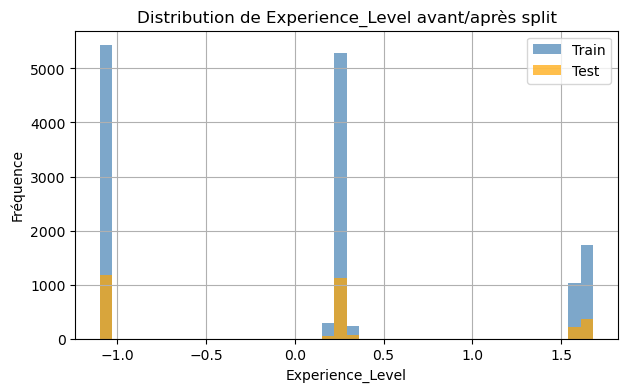

Train mean: 0.00, Test mean: -0.00


In [155]:
plt.figure(figsize=(7,4))
plt.hist(y_train_std, bins=40, alpha=0.7, label="Train", color="steelblue")
plt.hist(y_test_std, bins=40, alpha=0.7, label="Test", color="orange")
plt.legend()
plt.title(f"Distribution de {target_col} avant/après split")
plt.xlabel(target_col)
plt.ylabel("Fréquence")
plt.grid(True)
plt.show()

print(f"Train mean: {y_train_std.mean():.2f}, Test mean: {y_test_std.mean():.2f}")

### Export des sous-ensembles

In [156]:
# Export des X (déjà DataFrame)
X_train.to_parquet(export_dir / "X_train.parquet", index=False)
X_test.to_parquet(export_dir / "X_test.parquet", index=False)
X_val.to_parquet(export_dir / "X_val.parquet", index=False)

# Export des y standardisés (convertir ndarray → Series/DataFrame)
target_col_std = f"{target_col}_std"

pd.Series(y_train_std, name=target_col_std).to_frame() \
    .to_parquet(export_dir / "y_train.parquet", index=False)

pd.Series(y_test_std, name=target_col_std).to_frame() \
    .to_parquet(export_dir / "y_test.parquet", index=False)

pd.Series(y_val_std, name=target_col_std).to_frame() \
    .to_parquet(export_dir / "y_val.parquet", index=False)

## Sélection ou création de features pertinentes

In [157]:
X_train = pd.read_parquet(export_dir / "X_train.parquet")
X_test  = pd.read_parquet(export_dir / "X_test.parquet")
y_train = pd.read_parquet(export_dir / "y_train.parquet").squeeze()  # conversion en Series
y_test  = pd.read_parquet(export_dir / "y_test.parquet").squeeze() # conversion en Series


print(f"Données chargées : {X_train.shape[0]} lignes, {X_train.shape[1]} colonnes")
print(f"Données chargées : {X_test.shape[0]} lignes, {X_test.shape[1]} colonnes")

Données chargées : 13992 lignes, 8 colonnes
Données chargées : 2999 lignes, 8 colonnes

Données chargées : 2999 lignes, 8 colonnes


### Choix des features

#### Analyse de corrélation et importance des variables

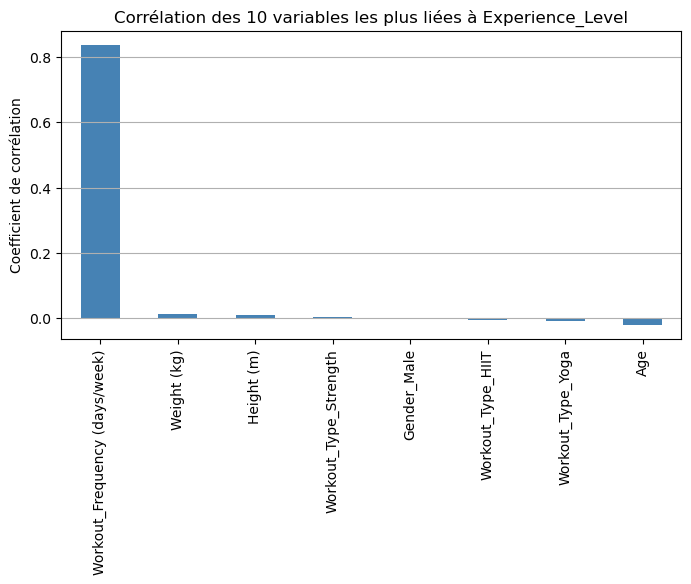


Variables NON présentes dans le TOP 10 corrélation :


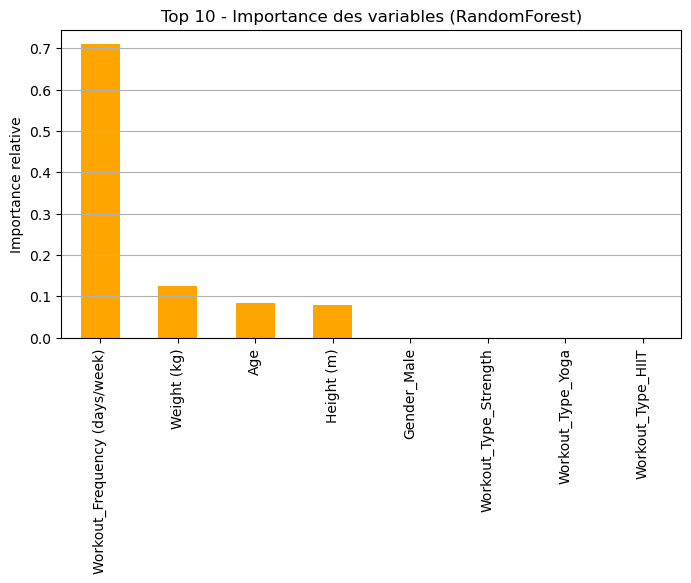


Variables NON présentes dans le TOP 10 importance RF :


In [158]:
# Calcul des corrélations (variables continues uniquement)
corr = X_train.corrwith(y_train).dropna().sort_values(ascending=False)
top_corr = corr.head(10)

plt.figure(figsize=(8,4))
top_corr.plot(kind="bar", color="steelblue")
plt.title(f"Corrélation des 10 variables les plus liées à {target_col}")
plt.ylabel("Coefficient de corrélation")
plt.grid(True, axis='y')
plt.show()

# Colonnes complètes
all_features = corr.index.tolist()

# Features non utilisées (hors Top 10 corrélation)
excluded_corr = [col for col in all_features if col not in top_corr.index]

print("\nVariables NON présentes dans le TOP 10 corrélation :")
for col in excluded_corr:
    print(" -", col)


# Modèle RandomForest pour importance des features
model_rf = RandomForestRegressor(random_state=42, n_estimators=100)
model_rf.fit(X_train, y_train)

importances = pd.Series(model_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top_importances = importances.head(10)

plt.figure(figsize=(8,4))
top_importances.plot(kind="bar", color="orange")
plt.title("Top 10 - Importance des variables (RandomForest)")
plt.ylabel("Importance relative")
plt.grid(True, axis='y')
plt.show()

# Colonnes complètes
all_features_importances = importances.index.tolist()

# Features non utilisées (hors Top 10 importance RF)
excluded_importances = [col for col in all_features_importances if col not in top_importances.index]

print("\nVariables NON présentes dans le TOP 10 importance RF :")
for col in excluded_importances:
    print(" -", col)

### Création de nouvelles features (inutiles dans les dernières versions post feature selection)

- BPM_effort_ratio = Avg_BPM / Max_BPM
- Fat_to_weight_ratio = Fat_Percentage / Weight (kg)
- Hydration_ratio = Water_Intake (liters) / Workout_Frequency (days/week)

In [159]:
def create_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # Ratios cardio
    if {"Avg_BPM", "Max_BPM"}.issubset(df.columns):
        df["BPM_effort_ratio"] = df["Avg_BPM"] / (df["Max_BPM"].replace(0, np.nan))
    # Composition corporelle
    if {"Fat_Percentage", "Weight (kg)"}.issubset(df.columns):
        df["Fat_to_weight_ratio"] = df["Fat_Percentage"] / (df["Weight (kg)"].replace(0, np.nan))
    # Hydratation relative
    if {"Water_Intake (liters)", "Workout_Frequency (days/week)"}.issubset(df.columns):
        df["Hydration_ratio"] = df["Water_Intake (liters)"] / (df["Workout_Frequency (days/week)"] + 1e-3)
    # Nettoyage inf/NaN générés par divisions
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.fillna(0)
    return df

### Réduction des features redondantes

Filtrage basé sur la matrice de corrélation et un seuil de tolérance pour supprimer les doublons d’information.

In [160]:
# Gestion du scaling
train_features = features_processed.copy()

# Ajouter les features dérivées si elles existent
extra_feats = ["BPM_effort_ratio", "Fat_to_weight_ratio", "Hydration_ratio"]
extra_feats = [c for c in extra_feats if c in X_train.columns]

for c in extra_feats:
    if c not in train_features:
        train_features.append(c)

print("Features utilisées par le modèle :", train_features)

# Extraction des matrices standardisées
X_train_scaled = X_train[train_features]
X_val_scaled   = X_val[train_features]
X_test_scaled  = X_test[train_features]

# Analyse de corrélation
if isinstance(X_train_scaled, np.ndarray):
    X_train_df = pd.DataFrame(X_train_scaled, columns=train_features)
else:
    X_train_df = X_train_scaled.copy()

corr_matrix = X_train_df.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [c for c in upper_tri.columns if any(upper_tri[c] > 0.95)]

print(f"Variables supprimées pour corrélation élevée (>0.95) : {len(to_drop)}")

X_train_reduced = X_train_df.drop(columns=to_drop, errors="ignore")
X_val_reduced   = X_val_scaled.drop(columns=to_drop, errors="ignore")
X_test_reduced  = X_test_scaled.drop(columns=to_drop, errors="ignore")

Features utilisées par le modèle : ['Age', 'Weight (kg)', 'Height (m)', 'Gender_Male', 'Workout_Frequency (days/week)', 'Workout_Type_HIIT', 'Workout_Type_Strength', 'Workout_Type_Yoga']
Variables supprimées pour corrélation élevée (>0.95) : 0


### Export des nouvelles données

In [161]:
feature_path = export_dir / "X_train_feature_engineered.parquet"
X_train_reduced.to_parquet(feature_path, index=False)

print(f"Export du jeu de données enrichi : {feature_path}")
print(f"Nombre final de colonnes : {X_train_reduced.shape[1]}")

feature_path = export_dir / "X_test_feature_engineered.parquet"
X_test_reduced.to_parquet(feature_path, index=False)

print(f"Export du jeu de données enrichi : {feature_path}")
print(f"Nombre final de colonnes : {X_test_reduced.shape[1]}")

feature_path = export_dir / "X_val_feature_engineered.parquet"
X_val_reduced.to_parquet(feature_path, index=False)

print(f"Export du jeu de données enrichi : {feature_path}")
print(f"Nombre final de colonnes : {X_val_reduced.shape[1]}")

Export du jeu de données enrichi : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\data\processed\life_style_data\X_train_feature_engineered.parquet
Nombre final de colonnes : 8
Export du jeu de données enrichi : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\data\processed\life_style_data\X_test_feature_engineered.parquet
Nombre final de colonnes : 8
Export du jeu de données enrichi : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\data\processed\life_style_data\X_val_feature_engineered.parquet
Nombre final de colonnes : 8


## Choix du modèle d’apprentissage supervisé

In [162]:
X_train = pd.read_parquet(export_dir / "X_train_feature_engineered.parquet")
y_train = pd.read_parquet(export_dir / "y_train.parquet").squeeze()
X_test = pd.read_parquet(export_dir / "X_test_feature_engineered.parquet")
y_test = pd.read_parquet(export_dir / "y_test.parquet").squeeze()
X_val = pd.read_parquet(export_dir / "X_val_feature_engineered.parquet")
y_val = pd.read_parquet(export_dir / "y_val.parquet").squeeze()

print(f"Données chargées : {X_train.shape[0]} lignes, {X_train.shape[1]} colonnes")
print(f"Données chargées : {X_test.shape[0]} lignes, {X_test.shape[1]} colonnes")
print(f"Données chargées : {X_val.shape[0]} lignes, {X_val.shape[1]} colonnes")

Données chargées : 13992 lignes, 8 colonnes
Données chargées : 2999 lignes, 8 colonnes
Données chargées : 2999 lignes, 8 colonnes


### Modèle de base : Régression linéaire

In [166]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train_std)
y_pred_lr_std = model_lr.predict(X_val)

mae_lr = mean_absolute_error(y_test, y_pred_lr_std)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr_std))
r2_lr = r2_score(y_test, y_pred_lr_std)

print(f"Régression linéaire --> MAE: {mae_lr:.2f}, RMSE: {rmse_lr:.2f}, R²: {r2_lr:.3f}")

Régression linéaire --> MAE: 1.07, RMSE: 1.30, R²: -0.702


#### Tuning LinearRegression

1. Ridge (Hyperparamètre : alpha - Plus alpha haut, plus la régularisation L2 est forte).
2. Lasso (Hyperparamètre : alpha - Coefficients exactement à zéro → très utile pour sélection de features)
3. ElasticNet (Hyperparamètres : alpha - l1_ratio (entre 0 et 1)

Comparaison des modèles linéaires (y standardisé)

LR (val)       → MAE=1.0702, RMSE=1.3045, R²=-0.7024
Ridge (val)    → MAE=1.0699, RMSE=1.3041, R²=-0.7014
   Best alpha  : 10
Lasso (val)    → MAE=1.0696, RMSE=1.3037, R²=-0.7003
   Best alpha  : 0.001
ElasticNet (val) → MAE=1.0647, RMSE=1.2981, R²=-0.6858
   Best params   : {'alpha': 0.01, 'l1_ratio': 0.5}

Résultats (triés par R² décroissant) :


Loading ITables v2.5.2 from the internet... (need help?)


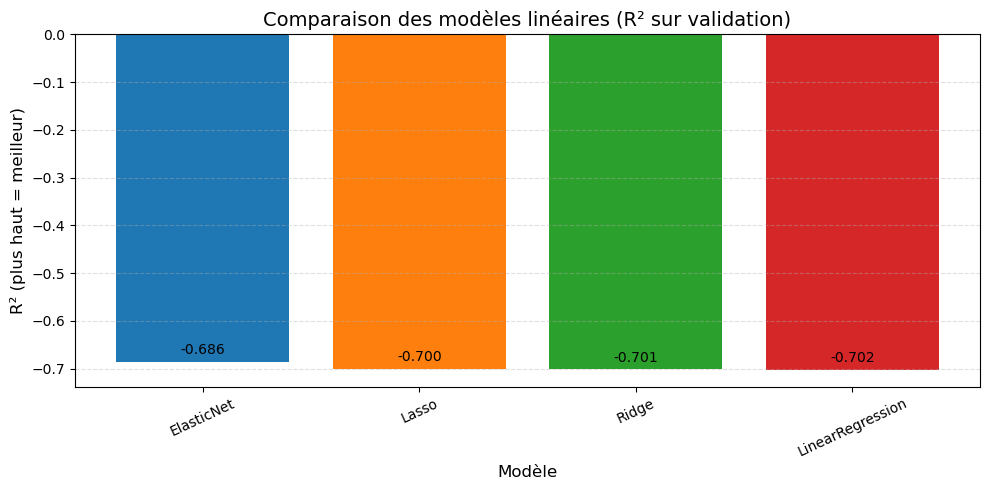

In [165]:
if search_best_params:
    print("Comparaison des modèles linéaires (y standardisé)\n")

    model_lr = LinearRegression()
    model_lr.fit(X_train, y_train_std)
    y_pred_lr = model_lr.predict(X_val)

    mae_lr  = mean_absolute_error(y_test, y_pred_lr)
    rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
    r2_lr   = r2_score(y_test, y_pred_lr)

    print(f"LR (val)       → MAE={mae_lr:.4f}, RMSE={rmse_lr:.4f}, R²={r2_lr:.4f}")

    # Ridge
    param_grid = {"alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10, 50, 100]}

    ridge = Ridge()
    ridge_cv = GridSearchCV(ridge, param_grid, cv=5, scoring="r2", n_jobs=-1)
    ridge_cv.fit(X_train, y_train_std)

    best_ridge = ridge_cv.best_estimator_
    y_pred_ridge = best_ridge.predict(X_val)

    mae_ridge  = mean_absolute_error(y_test, y_pred_ridge)
    rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
    r2_ridge   = r2_score(y_test, y_pred_ridge)

    print(f"Ridge (val)    → MAE={mae_ridge:.4f}, RMSE={rmse_ridge:.4f}, R²={r2_ridge:.4f}")
    print(f"   Best alpha  : {ridge_cv.best_params_['alpha']}")

    # Lasso
    lasso = Lasso(max_iter=20000)
    lasso_cv = GridSearchCV(lasso, param_grid, cv=5, scoring="r2", n_jobs=-1)
    lasso_cv.fit(X_train, y_train_std)

    best_lasso = lasso_cv.best_estimator_
    y_pred_lasso = best_lasso.predict(X_val)

    mae_lasso  = mean_absolute_error(y_test, y_pred_lasso)
    rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
    r2_lasso   = r2_score(y_test, y_pred_lasso)

    print(f"Lasso (val)    → MAE={mae_lasso:.4f}, RMSE={rmse_lasso:.4f}, R²={r2_lasso:.4f}")
    print(f"   Best alpha  : {lasso_cv.best_params_['alpha']}")

    # ElasticNet
    param_grid_en = {
        "alpha": [0.001, 0.01, 0.1, 1],
        "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
    }

    elastic = ElasticNet(max_iter=20000)
    elastic_cv = GridSearchCV(elastic, param_grid_en, cv=5, scoring="r2", n_jobs=-1)
    elastic_cv.fit(X_train, y_train_std)

    best_en = elastic_cv.best_estimator_
    y_pred_en = best_en.predict(X_val)

    mae_en  = mean_absolute_error(y_test, y_pred_en)
    rmse_en = np.sqrt(mean_squared_error(y_test, y_pred_en))
    r2_en   = r2_score(y_test, y_pred_en)

    print(f"ElasticNet (val) → MAE={mae_en:.4f}, RMSE={rmse_en:.4f}, R²={r2_en:.4f}")
    print(f"   Best params   : {elastic_cv.best_params_}")

    # Tableau récapitulatif
    results_lin = pd.DataFrame({
        "Modèle": ["LinearRegression", "Ridge", "Lasso", "ElasticNet"],
        "MAE":    [mae_lr, mae_ridge, mae_lasso, mae_en],
        "RMSE":   [rmse_lr, rmse_ridge, rmse_lasso, rmse_en],
        "R²":     [r2_lr, r2_ridge, r2_lasso, r2_en],
    })

    results_lin = results_lin.sort_values("R²", ascending=False).reset_index(drop=True)
    print("\nRésultats (triés par R² décroissant) :")
    show(results_lin)

    # Graphe comparatif des R²
    plt.figure(figsize=(10, 5))

    bars = plt.bar(
        results_lin["Modèle"], 
        results_lin["R²"], 
        color=plt.cm.tab10.colors  # palette plus lisible
    )

    plt.title("Comparaison des modèles linéaires (R² sur validation)", fontsize=14)
    plt.ylabel("R² (plus haut = meilleur)", fontsize=12)
    plt.xlabel("Modèle", fontsize=12)
    plt.xticks(rotation=25)

    # Grille légère
    plt.grid(axis="y", linestyle="--", alpha=0.4)

    # Valeurs affichées au-dessus des barres
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

### Random Forest

#### Base Random Forest

Le Random Forest Regressor capture les relations non linéaires entre les variables.

In [168]:
model_rf = RandomForestRegressor(random_state=42, n_estimators=200, max_depth=None)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest --> MAE: {mae_rf:.10f}, RMSE: {rmse_rf:.10f}, R²: {r2_rf:.10f}")

Random Forest --> MAE: 0.0374011820, RMSE: 0.0902607471, R²: 0.9918493925


#### Tuning Random Forest
- n_estimators : nb d’arbres
- max_depth : profondeur max
- min_samples_split / min_samples_leaf : taille mini des noeuds
- max_features : nb de features considérées à chaque split
- bootstrap / oob_score : échantillonnage avec remise + score OOB

In [169]:
if search_best_params:
    print("Tuning RandomForestRegressor\n")

    # Modèle de base (pour comparaison)
    base_rf = RandomForestRegressor(
        random_state=42,
        n_estimators=200,
        max_depth=None
    )
    base_rf.fit(X_train, y_train)
    y_pred_base = base_rf.predict(X_test)

    mae_base = mean_absolute_error(y_test, y_pred_base)
    rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
    r2_base   = r2_score(y_test, y_pred_base)

    print(f"RF baseline → MAE: {mae_base:.10f}, RMSE: {rmse_base:.10f}, R²: {r2_base:.10f}")

    # Espace de recherche des hyperparamètres
    param_dist = {
        "n_estimators": randint(100, 600),
        "max_depth": [None] + list(range(4, 21, 2)),
        "min_samples_split": randint(2, 11),
        "min_samples_leaf": randint(1, 6),
        "max_features": ["sqrt", "log2", None, 0.5],
        "bootstrap": [True, False],
    }


    rf = RandomForestRegressor(random_state=42)

    search_rf = RandomizedSearchCV(
        estimator=rf,
        param_distributions=param_dist,
        n_iter=N_ITER,
        scoring="r2",
        cv=3,
        n_jobs=-1,
        verbose=1,
        random_state=42,
    )

    search_rf.fit(X_train, y_train)

    print("\nMeilleurs hyperparamètres trouvés :")
    print(search_rf.best_params_)

    best_rf = search_rf.best_estimator_

    # Évaluation sur le test
    y_pred_best = best_rf.predict(X_test)

    mae_best = mean_absolute_error(y_test, y_pred_best)
    rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
    r2_best   = r2_score(y_test, y_pred_best)

    print("\nPerformance RandomForest optimisée :")
    print(f"RF best     --> MAE: {mae_best:.10f}, RMSE: {rmse_best:.10f}, R²: {r2_best:.10f}")

    print("\nComparatif rapide :")
    print(f"Baseline RF --> MAE: {mae_base:.10f}, RMSE: {rmse_base:.10f}, R²: {r2_base:.10f}")
    print(f"Best RF     --> MAE: {mae_best:.10f}, RMSE: {rmse_best:.10f}, R²: {r2_best:.10f}")

Tuning RandomForestRegressor

RF baseline → MAE: 0.0374011820, RMSE: 0.0902607471, R²: 0.9918493925
Fitting 3 folds for each of 100 candidates, totalling 300 fits

Meilleurs hyperparamètres trouvés :
{'bootstrap': False, 'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 159}

Performance RandomForest optimisée :
RF best     --> MAE: 0.0542714747, RMSE: 0.1038623271, R²: 0.9892078436

Comparatif rapide :
Baseline RF --> MAE: 0.0374011820, RMSE: 0.0902607471, R²: 0.9918493925
Best RF     --> MAE: 0.0542714747, RMSE: 0.1038623271, R²: 0.9892078436


#### Sélection du meilleur modèle entre model_rf, base_rf et best_rf

In [170]:
if search_best_params:
    # Règle : on maximise R², puis on minimise MAE, puis RMSE
    candidates = {
        "model_rf": {
            "model": model_rf,
            "mae": mae_rf,
            "rmse": rmse_rf,
            "r2": r2_rf
        }
    }

    # Ajouter la baseline si disponible
    if "base_rf" in locals() and "mae_base" in locals():
        candidates["base_rf"] = {
            "model": base_rf,
            "mae": mae_base,
            "rmse": rmse_base,
            "r2": r2_base
        }

    # Ajouter le best_rf si dispo (search_best_params = True + fit OK)
    if "best_rf" in locals() and "mae_best" in locals():
        candidates["best_rf"] = {
            "model": best_rf,
            "mae": mae_best,
            "rmse": rmse_best,
            "r2": r2_best
        }

    # Sélection du meilleur candidat
    best_key = max(
        candidates.keys(),
        key=lambda k: (candidates[k]["r2"], -candidates[k]["mae"], -candidates[k]["rmse"])
    )

    best_info = candidates[best_key]

    print("\nComparatif des modèles :")
    for name, info in candidates.items():
        print(
            f"- {name:<9} → MAE: {info['mae']:.10f}, "
            f"RMSE: {info['rmse']:.10f}, R²: {info['r2']:.10f}"
        )

    print(f"\nModèle sélectionné : {best_key}")
    print(
        f"   → MAE: {best_info['mae']:.10f}, "
        f"RMSE: {best_info['rmse']:.10f}, R²: {best_info['r2']:.10f}"
    )

    # Variable finale : model_rf
    model_rf = best_info["model"]


Comparatif des modèles :
- model_rf  → MAE: 0.0374011820, RMSE: 0.0902607471, R²: 0.9918493925
- base_rf   → MAE: 0.0374011820, RMSE: 0.0902607471, R²: 0.9918493925
- best_rf   → MAE: 0.0542714747, RMSE: 0.1038623271, R²: 0.9892078436

Modèle sélectionné : model_rf
   → MAE: 0.0374011820, RMSE: 0.0902607471, R²: 0.9918493925


### Bagging Regressor

#### Base Bagging Regressor

Bagging Regressor repose sur le principe du Bootstrap Aggregating = parallèle plusieurs modèles faibles, sur batch, puis moyenne.

In [171]:
model_bag = BaggingRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model_bag.fit(X_train, y_train)
y_pred_bag = model_bag.predict(X_test)

mae_bag = mean_absolute_error(y_test, y_pred_bag)
rmse_bag = np.sqrt(mean_squared_error(y_test, y_pred_bag))
r2_bag = r2_score(y_test, y_pred_bag)

print(f"Bagging Regressor --> MAE: {mae_bag:.10f}, RMSE: {rmse_bag:.10f}, R²: {r2_bag:.10f}")

Bagging Regressor --> MAE: 0.0372988407, RMSE: 0.0903030449, R²: 0.9918417517


#### Tuning Bagging Regressor
- n_estimators : nombre d’arbres,
- max_samples : proportion d’échantillons utilisés par arbre,
- max_features : proportion de features utilisées par arbre,
- bootstrap / bootstrap_features : tirage avec ou sans remise.

In [172]:
if search_best_params:
    print("Tuning BaggingRegressor\n")

    # Baseline Bagging
    base_bag = BaggingRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    base_bag.fit(X_train, y_train)
    y_pred_base = base_bag.predict(X_test)

    mae_base = mean_absolute_error(y_test, y_pred_base)
    rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
    r2_base   = r2_score(y_test, y_pred_base)

    print(f"Bagging baseline --> MAE: {mae_base:.4f}, RMSE: {rmse_base:.4f}, R²: {r2_base:.4f}")

    # Espace de recherche des hyperparamètres
    param_dist_bag = {
        "n_estimators": randint(100, 600),
        "max_samples": uniform(0.5, 0.5),      # entre 0.5 et 1.0
        "max_features": uniform(0.5, 0.5),     # entre 0.5 et 1.0
        "bootstrap": [True, False],
        "bootstrap_features": [False, True],
    }

    bag = BaggingRegressor(
        random_state=42,
        n_jobs=-1
    )

    search_bag = RandomizedSearchCV(
        estimator=bag,
        param_distributions=param_dist_bag,
        n_iter=N_ITER,
        scoring="r2",
        cv=3,
        n_jobs=-1,
        verbose=1,
        random_state=42
    )

    search_bag.fit(X_train, y_train)

    print("\nMeilleurs hyperparamètres Bagging :")
    print(search_bag.best_params_)

    best_bag = search_bag.best_estimator_

    # Évaluation sur le test
    y_pred_best = best_bag.predict(X_test)

    mae_best = mean_absolute_error(y_test, y_pred_best)
    rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
    r2_best   = r2_score(y_test, y_pred_best)

    print("\nPerformance Bagging optimisé :")
    print(f"Bagging best     --> MAE: {mae_best:.10f}, RMSE: {rmse_best:.10f}, R²: {r2_best:.10f}")

    print("\nComparatif rapide :")
    print(f"Bagging baseline --> MAE: {mae_base:.10f}, RMSE: {rmse_base:.10f}, R²: {r2_base:.10f}")
    print(f"Bagging best    --> MAE: {mae_best:.10f}, RMSE: {rmse_best:.10f}, R²: {r2_best:.10f}")

Tuning BaggingRegressor

Bagging baseline --> MAE: 0.0373, RMSE: 0.0903, R²: 0.9918
Fitting 3 folds for each of 100 candidates, totalling 300 fits

Meilleurs hyperparamètres Bagging :
{'bootstrap': False, 'bootstrap_features': False, 'max_features': np.float64(0.9281621459390462), 'max_samples': np.float64(0.702254063561095), 'n_estimators': 260}

Performance Bagging optimisé :
Bagging best     --> MAE: 0.0547698863, RMSE: 0.1058376084, R²: 0.9887934439

Comparatif rapide :
Bagging baseline --> MAE: 0.0372988407, RMSE: 0.0903030449, R²: 0.9918417517
Bagging best    --> MAE: 0.0547698863, RMSE: 0.1058376084, R²: 0.9887934439


#### 10.4.3. Sélection du meilleur modèle Bagging : model_bag vs base_bag vs best_bag

In [ ]:
if search_best_params:
    # Critères : maximiser R², puis minimiser MAE, puis RMSE
    candidates_bag = {
        "model_bag": {
            "model": model_bag,
            "mae": mae_bag,
            "rmse": rmse_bag,
            "r2": r2_bag
        }
    }

    # Ajouter baseline si elle existe
    if "base_bag" in locals() and "mae_base" in locals():
        candidates_bag["base_bag"] = {
            "model": base_bag,
            "mae": mae_base,
            "rmse": rmse_base,
            "r2": r2_base
        }

    # Ajouter best_bag si tuning activé et résultat disponible
    if "best_bag" in locals() and "mae_best" in locals():
        candidates_bag["best_bag"] = {
            "model": best_bag,
            "mae": mae_best,
            "rmse": rmse_best,
            "r2": r2_best
        }

    # Sélection du meilleur modèle
    best_key_bag = max(
        candidates_bag.keys(),
        key=lambda k: (candidates_bag[k]["r2"], -candidates_bag[k]["mae"], -candidates_bag[k]["rmse"])
    )

    best_info_bag = candidates_bag[best_key_bag]

    print("\nComparatif des modèles Bagging :")
    for name, info in candidates_bag.items():
        print(
            f"- {name:<10} → MAE: {info['mae']:.10f}, "
            f"RMSE: {info['rmse']:.10f}, R²: {info['r2']:.10f}"
        )

    print(f"\nModèle Bagging sélectionné : {best_key_bag}")
    print(
        f"   --> MAE: {best_info_bag['mae']:.10f}, "
        f"RMSE: {best_info_bag['rmse']:.10f}, R²: {best_info_bag['r2']:.10f}"
    )

    # Variable finale : model_bag
    model_bag = best_info_bag["model"]

### Gradient Boosting

#### Base Gradient Boosting

Gradient Boosting Regressor --> petits modèles faibles pour corriger les erreurs du précédent.

In [173]:
model_gb = GradientBoostingRegressor(random_state=42, n_estimators=300, learning_rate=0.05, max_depth=3)
model_gb.fit(X_train, y_train)
y_pred_gb = model_gb.predict(X_test)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print(f"Gradient Boosting --> MAE: {mae_gb:.10f}, RMSE: {rmse_gb:.10f}, R²: {r2_gb:.10f}")

Gradient Boosting --> MAE: 0.3302393366, RMSE: 0.4248934486, R²: 0.8193856709


#### Tuning Gradient Boosting
- n_estimators
- learning_rate
- max_depth
- min_samples_split, min_samples_leaf
- subsample (stochastic gradient boosting)
- max_features

In [174]:
if search_best_params:
    print("Tuning GradientBoostingRegressor\n")

    # Baseline GB
    base_gb = GradientBoostingRegressor(
        random_state=42,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
    )

    base_gb.fit(X_train, y_train)
    y_pred_base = base_gb.predict(X_test)

    mae_base = mean_absolute_error(y_test, y_pred_base)
    rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
    r2_base   = r2_score(y_test, y_pred_base)

    print(f"GB baseline → MAE: {mae_base:.10f}, RMSE: {rmse_base:.10f}, R²: {r2_base:.10f}")

    # Espace de recherche des hyperparamètres
    param_dist_gb = {
        "n_estimators": randint(150, 800),          # nb d'arbres
        "learning_rate": uniform(0.01, 0.19),       # ~ [0.01, 0.20]
        "max_depth": randint(2, 7),                 # profondeur des arbres
        "min_samples_split": randint(2, 11),
        "min_samples_leaf": randint(1, 6),
        "subsample": uniform(0.5, 0.5),             # [0.5, 1.0] → stochastic GB
        "max_features": [None, "sqrt", "log2"],
    }

    gb = GradientBoostingRegressor(random_state=42)

    search_gb = RandomizedSearchCV(
        estimator=gb,
        param_distributions=param_dist_gb,
        n_iter=N_ITER,              
        scoring="r2",
        cv=3,
        n_jobs=-1,
        verbose=1,
        random_state=42,
    )

    search_gb.fit(X_train, y_train)

    print("\nMeilleurs hyperparamètres GB :")
    print(search_gb.best_params_)

    best_gb = search_gb.best_estimator_

    # Évaluation sur le test
    y_pred_best = best_gb.predict(X_test)

    mae_best = mean_absolute_error(y_test, y_pred_best)
    rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
    r2_best   = r2_score(y_test, y_pred_best)

    print("\nPerformance Gradient Boosting optimisé :")
    print(f"GB best      --> MAE: {mae_best:.10f}, RMSE: {rmse_best:.10f}, R²: {r2_best:.10f}")

    print("\nComparatif rapide :")
    print(f"GB baseline  --> MAE: {mae_base:.10f}, RMSE: {rmse_base:.10f}, R²: {r2_base:.10f}")
    print(f"GB best      --> MAE: {mae_best:.10f}, RMSE: {rmse_best:.10f}, R²: {r2_best:.10f}")

Tuning GradientBoostingRegressor

GB baseline → MAE: 0.3302393366, RMSE: 0.4248934486, R²: 0.8193856709
Fitting 3 folds for each of 100 candidates, totalling 300 fits

Meilleurs hyperparamètres GB :
{'learning_rate': np.float64(0.14577322531301184), 'max_depth': 6, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 596, 'subsample': np.float64(0.7178364493389455)}

Performance Gradient Boosting optimisé :
GB best      --> MAE: 0.0807246712, RMSE: 0.1306996052, R²: 0.9829100542

Comparatif rapide :
GB baseline  --> MAE: 0.3302393366, RMSE: 0.4248934486, R²: 0.8193856709
GB best      --> MAE: 0.0807246712, RMSE: 0.1306996052, R²: 0.9829100542


#### Sélection du meilleur modèle Gradient Boosting : model_gb vs base_gb vs best_gb

In [ ]:
if search_best_params:
    # Critères : maximiser R², puis minimiser MAE, puis RMSE
    candidates_gb = {
        "model_gb": {
            "model": model_gb,
            "mae": mae_gb,
            "rmse": rmse_gb,
            "r2": r2_gb
        }
    }

    # Ajouter baseline si elle existe
    if "base_gb" in locals() and "mae_base" in locals():
        candidates_gb["base_gb"] = {
            "model": base_gb,
            "mae": mae_base,
            "rmse": rmse_base,
            "r2": r2_base
        }

    # Ajouter best_gb si tuning activé et résultat disponible
    if "best_gb" in locals() and "mae_best" in locals():
        candidates_gb["best_gb"] = {
            "model": best_gb,
            "mae": mae_best,
            "rmse": rmse_best,
            "r2": r2_best
        }

    # Sélection du meilleur modèle
    best_key_gb = max(
        candidates_gb.keys(),
        key=lambda k: (candidates_gb[k]["r2"], -candidates_gb[k]["mae"], -candidates_gb[k]["rmse"])
    )

    best_info_gb = candidates_gb[best_key_gb]

    print("\nComparatif des modèles Gradient Boosting :")
    for name, info in candidates_gb.items():
        print(
            f"- {name:<10} → MAE: {info['mae']:.10f}, "
            f"RMSE: {info['rmse']:.10f}, R²: {info['r2']:.10f}"
        )

    print(f"\nModèle Gradient Boosting sélectionné : {best_key_gb}")
    print(
        f"   → MAE: {best_info_gb['mae']:.10f}, "
        f"RMSE: {best_info_gb['rmse']:.10f}, R²: {best_info_gb['r2']:.10f}"
    )

    # Variable finale : model_gb
    model_gb = best_info_gb["model"]

### 10.6. Modèle non paramétrique : K-Nearest Neighbors (optionnel - pour aller plus loin)
Le modèle K-NN sert ici de baseline non paramétrique.

Il prédit la cible en moyennant les échantillons les plus proches selon une distance euclidienne normalisée.

Son intérêt est de vérifier si une structure locale simple existe dans les données.

Toutefois, ses coûts de prédiction élevés et sa sensibilité au nombre de dimensions en font un modèle peu adapté à un pipeline temps réel ou scalé.

Il est conservé ici pour enrichir la comparaison inter-modèles, mais ne constitue pas un candidat prioritaire pour le modèle final.

In [ ]:
# --- Modèle KNN ---
model_knn = KNeighborsRegressor(
    n_neighbors=5,        # valeur standard
    weights="distance",   # pondère les voisins par proximité
    metric="minkowski",   # distance euclidienne (p=2)
    p=2
)

model_knn.fit(X_train, y_train)
y_pred_knn = model_knn.predict(X_test)

# --- Métriques ---
mae_knn = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)

print(f"\nKNN Regressor → MAE: {mae_knn:.10f}, RMSE: {rmse_knn:.10f}, R²: {r2_knn:.10f}")

### 10.6. Comparaison des modèles

On compare les modèles selon trois métriques principales :
- MAE (Mean Absolute Error) : erreur moyenne absolue ;
- RMSE (Root Mean Squared Error) : pénalise davantage les grosses erreurs ;
- R² : proportion de variance expliquée par le modèle (plus proche de 1 = meilleur).

In [ ]:
results = pd.DataFrame({
    "Modèle": ["Régression Linéaire", "Random Forest", "Bagging Regressor", "Gradient Boosting", "KNN Regressor"],
    "MAE": [mae_lr, mae_rf, mae_bag, mae_gb, mae_knn],
    "RMSE": [rmse_lr, rmse_rf, rmse_bag, rmse_gb, rmse_knn],
    "R²": [r2_lr, r2_rf, r2_bag, r2_gb, r2_knn]
})

display(results.sort_values("R²", ascending=False).reset_index(drop=True))

### 10.7.  Sélection du meilleur modèle

In [ ]:
# Mapping noms → objets modèles
models_dict = {
    "Régression Linéaire": model_lr,
    "Random Forest": model_rf,
    "Bagging Regressor": model_bag,
    "Gradient Boosting": model_gb,
    "KNN Regressor": model_knn,
}

# Recherche du nom du meilleur modèle basé sur le R²
best_model_name = results.sort_values("R²", ascending=False).iloc[0]["Modèle"]
best_model = models_dict[best_model_name]

print(f"Meilleur modèle sélectionné : {best_model_name}")
best_model

### 10.8. Gestion du scaling

In [ ]:
# X_* sont déjà standardisés par le bloc précédent
X_train_scaled = X_train[features_processed].values
X_val_scaled   = X_val[features_processed].values
X_test_scaled  = X_test[features_processed].values

y_train_scaled = y_train_std  # déjà standardisé
y_val_scaled   = y_val_std
y_test_scaled  = y_test_std

### 10.9. Entraînement

In [ ]:
# --- Entraînement du modèle sur données normalisées
best_model.fit(X_train_scaled, y_train_scaled)

### 10.10. Vérifier la variance du dataset

In [ ]:
# Sanity check variabilité
print("Variance moyenne des features :", np.mean(np.var(X_train_scaled, axis=0)))
print("Variance de la cible :", np.var(y_train_scaled))
y_check = best_model.predict(X_train_scaled[:10])
print("Prédictions sur 10 échantillons :", np.round(y_check, 4))
y_check_kcal = target_scaler.inverse_transform(y_check.reshape(-1, 1)).ravel()
print("Prédictions sur 10 échantillons (kcal) :", np.round(y_check_kcal, 2))

### 10.11. Vérification des features

In [ ]:
feature_names = X_train[best_model.feature_names_in_].columns.tolist() \
    if hasattr(best_model, "feature_names_in_") else X_train.columns.tolist()

setattr(best_model, "feature_names_in_", np.array(feature_names, dtype=object))
print(list(best_model.feature_names_in_))

### 10.12. Sauvegarde des scalers pour être en phase avec "test_model.ipynb" et Gradio

In [ ]:
# (optionnel) petite sanity-check sur 10 prédictions test
# On utilise le même espace de features que pour l'entraînement
y_test_pred_std = best_model.predict(X_test_scaled)
y_test_pred_kcal = target_scaler.inverse_transform(y_test_pred_std.reshape(-1, 1)).ravel()
print("Extrait prédictions (entre 1 et 3.05):", np.round(y_test_pred_kcal[:10], 2))

### 10.13. Sauvegarde du modèle sélectionné

In [ ]:
# Injecter les noms de features (ordre)
setattr(best_model, "feature_names_in_", np.array(feature_names, dtype=object))

# Sauvegarde
joblib.dump(best_model, model_dir / "model.joblib")
print("Modèle et scalers sauvegardés dans :", model_dir)

### 10.14. Validation : chargement et fusion X_val + y_val (en unités réelles)

In [ ]:
X_val = pd.read_parquet(export_dir / "X_val_feature_engineered.parquet")
y_val = pd.read_parquet(export_dir / "y_val.parquet").squeeze()

df_val = pd.concat([X_val, y_val], axis=1)

### 10.15. Export vers SQLite pour inspection manuelle

In [ ]:
con = sqlite3.connect(export_dir / "life_style_data_val.db")
df_val.to_sql("validation_set", con, if_exists="replace", index=False)
con.close()

print(f"Fusion et export terminés : {df_val.shape[0]} lignes, {df_val.shape[1]} colonnes")

### 10.16. Informations relatives au choix du modèle (son nom et les métriques associées)

In [ ]:
# Détection "friendly" du type de modèle
def model_friendly_name(est):
    if isinstance(est, RandomForestRegressor):
        return "Random Forest"
    if isinstance(est, BaggingRegressor):
        return "Bagging Regressor"
    if isinstance(est, GradientBoostingRegressor):
        return "Gradient Boosting"
    if isinstance(est, LinearRegression):
        return "Régression Linéaire"
    if isinstance(est, KNeighborsRegressor):
        return "KNN Regressor"
    return est.__class__.__name__

# Métriques par modèle (cast en float pour le JSON)
metrics = {
    "Linear Regression": {
        "MAE": float(mae_lr), "RMSE": float(rmse_lr), "R2": float(r2_lr)
    },
    "Random Forest": {
        "MAE": float(mae_rf), "RMSE": float(rmse_rf), "R2": float(r2_rf)
    },
    "Bagging Regressor": {
        "MAE": float(mae_bag), "RMSE": float(rmse_bag), "R2": float(r2_bag)
    },
    "Gradient Boosting": {
        "MAE": float(mae_gb), "RMSE": float(rmse_gb), "R2": float(r2_gb)
    },
    "KNN Regressor": {
        "MAE": float(mae_knn), "RMSE": float(rmse_knn), "R2": float(r2_knn)
    }
}

# Infos sur le modèle sélectionné
model_filename = "model.joblib"  # correspond à ton dump: joblib.dump(best_model, model_dir / "model.joblib")
model_path = (model_dir / model_filename).resolve()

best_info = {
    "model_type": model_friendly_name(best_model),
    "model_class": best_model.__class__.__name__,
    "model_path": str(model_path),
    "params": best_model.get_params()
}

# Contexte d’évaluation
report = {
    "created_at": datetime.utcnow().isoformat() + "Z",
    "target": y.name if hasattr(y, "name") else target_col,
    "n_features": int(X_test.shape[1]) if "X_test" in globals() else None,
    "n_test_samples": int(len(y_test)) if "y_test" in globals() else None,
    "metrics_by_model": metrics,
    "selected_model": best_info
}

# Sauvegarde
report_path = model_dir / "model_report.json"
with open(report_path, "w", encoding="utf-8") as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

print(f"Rapport JSON enregistré : {report_path}")

### 10.17. Plan de features

In [ ]:
# --- Ordre prioritaire pour les features dans le schéma / UI ---
FEATURE_PRIORITY = ["Experience_Level"]

# Liste finale ordonnée
ordered_features: list[str] = []

# 1) On met d'abord les features prioritaires si elles existent
for feat in FEATURE_PRIORITY:
    if feat in selected_features and feat not in ordered_features:
        ordered_features.append(feat)

# 2) On ajoute toutes les autres dans l'ordre original
for feat in selected_features:
    if feat not in ordered_features:
        ordered_features.append(feat)

# On part maintenant de ordered_features (et plus selected_features) pour le schéma
train_cols = ordered_features
schema_features = []

for col in ordered_features:
    if col in inference:
        spec = {"name": col, **inference[col], "required": True}
    elif col in X_train.columns:
        spec = {"name": col, **infer_field_spec(col, X_train[col]), "required": True}
    else:
        spec = {"name": col, "type": "string", "required": True}

    schema_features.append(spec)

# Exemple de payload (médiane/mode depuis X_train, sinon placeholders)
example = {}
for f in schema_features:
    name, ftype = f["name"], f["type"]
    if name in X_train.columns:
        s = X_train[name]
        if ftype in {"integer", "number"}:
            val = float(s.median()) if s.notna().any() else (f.get("min") or 0)
            if ftype == "integer":
                val = int(round(val))
            example[name] = val
        else:
            if "enum" in f:
                example[name] = f["enum"][0]
            elif s.dropna().size > 0:
                example[name] = str(s.dropna().iloc[0])
            else:
                example[name] = ""
    else:
        if ftype in {"integer", "number"}:
            example[name] = f.get("min", 0)
        else:
            example[name] = f.get("enum", [""])[0] if f.get("enum") else ""

# Objet final du schéma
feature_schema = {
    "model_name": "life_style_data",
    "model_version": MODEL_VERSION,
    "created_at": datetime.utcnow().isoformat() + "Z",
    "target": y.name if isinstance(y, pd.Series) else FEATURE_PRIORITY,
    "features": schema_features, # ordre = contrat d’entrée
    "ordering_guarantee": True, # l’ordre des features est garanti
    "one_hot_handle_unknown": "ignore", # convention côté pipeline
    "notes": "Schéma d’entrée pour l’inférence REST. Les features dérivées encodages sont calculées côté backend.",
    "example_payload": example
}
# Sauvegarde
schema_path = model_dir / "feature_schema.json"
with open(schema_path, "w", encoding="utf-8") as f:
    json.dump(feature_schema, f, ensure_ascii=False, indent=2)
print(f"Schéma d’entrée sauvegardé : {schema_path.name}")

Critères de validation :
- Modèle entraîné sans erreur ni surapprentissage excessif ;
- Comparaison objective des métriques (MAE, RMSE, R²) ;
- Sauvegarde du meilleur modèle pour l’étape d’optimisation.

Cette section valide le choix du modèle de base et ouvre la voie à la phase 7 — Entraînement, validation et évaluation des performances.

### 10.18. Sélection du meilleur modèle

Le modèle offrant le meilleur R² et la plus faible erreur (MAE/RMSE) est sélectionné pour les étapes suivantes :
- interprétation des résultats,
- optimisation des hyperparamètres (section suivante),
- et déploiement dans le pipeline complet.

## 11. Code complet avec pipeline

In [ ]:
# pipeline = Pipeline(steps=[
#     ('imputer', SimpleImputer(strategy='median')),
#     ('scaler', StandardScaler()),
#     ('model', LinearRegression())
# ])

# # Pipeline générique
# pipeline = Pipeline(steps=[
#     ("features", FunctionTransformer(create_features, validate=False)),
#     ("scaler", "passthrough"),  # sera remplacé par StandardScaler pour les modèles qui en ont besoin
#     ("model", RandomForestRegressor(random_state=42))  # placeholder
# ])

In [ ]:
# # Grille de modèles & hyperparamètres
# param_grid = [
#     # A) Random Forest (pas de scaling requis)
#     {
#         "scaler": ["passthrough"],
#         "model": [RandomForestRegressor(random_state=42)],
#         "model__n_estimators": [200, 400],
#         "model__max_depth": [None, 10, 20],
#         "model__min_samples_split": [2, 5]
#     },
#     # B) Gradient Boosting (pas de scaling requis)
#     {
#         "scaler": ["passthrough"],
#         "model": [GradientBoostingRegressor(random_state=42)],
#         "model__n_estimators": [200, 300],
#         "model__learning_rate": [0.05, 0.1],
#         "model__max_depth": [2, 3]
#     },
#     # C) Régression linéaire (scaling nécessaire)
#     {
#         "scaler": [StandardScaler(with_mean=True, with_std=True)],
#         "model": [LinearRegression()]
#         # Pas d'hyperparamètres pour LinearRegression standard
#     }
# ]

# # CV + métriques
# cv = KFold(n_splits=5, shuffle=True, random_state=42)

# grid = GridSearchCV(
#     estimator=pipeline,
#     param_grid=param_grid,
#     scoring={"rmse": "neg_root_mean_squared_error", "r2": "r2"},
#     refit="r2",                # on conserve le meilleur modèle au sens du R²
#     cv= cv,
#     n_jobs=-1,
#     verbose=1
# )

In [ ]:
# # pipeline.fit(X_train, y_train)
# grid.fit(X_train, y_train)
# print("Best params:", grid.best_params_)
# print("Best CV R² :", grid.best_score_)

In [ ]:
# # y_pred = pipeline.predict(X_test)
# # pd.DataFrame(y_pred,columns=['Predicted_PRICE'])

# best_model = grid.best_estimator_
# # y_pred = best_model.predict(X_test)

# # mae  = mean_absolute_error(y_test, y_pred)
# # rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# # r2   = r2_score(y_test, y_pred)

# # print(f"Test → MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.3f}")

# # 2.2 Appliquer EXACTEMENT les mêmes features aux deux
# df_x = pd.DataFrame(X_val)
# print(df_x)

# y_pred = best_model.predict(X_val)
# # test_pred = best_model.predict(X_test)
# # print(f"Test R²: {r2_score(y_test, test_pred):.3f}")

# mae  = mean_absolute_error(y_test, y_pred)
# rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# r2   = r2_score(y_test, y_pred)

# print(f"Test → MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.3f}")

# df_val = pd.DataFrame(y_pred)
# df_val
# # df_val = pd.DataFrame(y_pred,columns=['Predicted_PRICE'])
# # y_pred

In [ ]:
# # Modèle
# model_path = model_dir / "best_pipeline_model.joblib"
# joblib.dump(best_model, model_path)

# # Petit rapport
# report = {
#     "best_params": grid.best_params_,
#     "cv_best_r2": float(grid.best_score_),
#     "test_mae": float(mae),
#     "test_rmse": float(rmse),
#     "test_r2": float(r2),
#     "n_features_in": int(X_train.shape[1])
# }
# pd.Series(report).to_json(export_dir / "best_pipeline_model_report.json", indent=2)

# print(f"✔ Modèle sauvegardé → {model_path}")
# print("✔ Rapport → best_supervised_model_report.json")


Conseils d’usage / bonnes pratiques (rapides)
- Zéro fuite de données : le scaler est dans la pipeline, appris uniquement sur le train.
- Même feature engineering partout : FunctionTransformer garantit l’application identique sur train/test.
- Comparaison saine : trois familles de modèles testées, avec une grille raisonnable pour démarrer.
- Prochain step : section “7. Entraînement, validation, évaluation des performances” → on étendra la grille (ou on basculera sur RandomizedSearchCV / Optuna) et on ajoutera des courbes d’apprentissage et permutation importances.

## 12. Conversion df_val to SQLLite


In [ ]:
# # Chargement
# X_feature_val = pd.read_parquet(export_dir / "X_val_feature_engineered.parquet")
# X_val = pd.read_parquet(export_dir / "X_val.parquet")
# y_val = pd.read_parquet(export_dir / "y_val.parquet").squeeze()

# # Connexion SQLite
# # con = sqlite3.connect(export_dir / "life_style_data_val.db")

# # Fusion sur position (même ordre)
# df_val = pd.concat([X_feature_val, y_val], axis=1)

# # Export
# df_val.to_sql("validation_feature_set", con, if_exists="replace", index=False)


# # Fusion sur position (même ordre)
# df_val = pd.concat([X_val, y_val], axis=1)

# # Export
# df_val.to_sql("validation_set", con, if_exists="replace", index=False)

# con.close()

# print(f"✔ Fusion et export terminés : {df_val.shape[0]} lignes, {df_val.shape[1]} colonnes")


## 13. Nettoyage post-traitement

In [ ]:
# Suppression des fichiers parquet générés (X/Y train/val/test + feature_engineered)
files_to_delete = [
    "X_train.parquet",
    "X_train_feature_engineered.parquet",
    "X_val.parquet",
    "X_val_feature_engineered.parquet",
    "X_test.parquet",
    "X_test_feature_engineered.parquet",
    "y_train.parquet",
    "y_val.parquet",
    "y_test.parquet",

    "life_style_data_clean.parquet",
    "life_style_data_encoded.parquet",
    "life_style_data_feature.parquet",
    "life_style_data_scaled.parquet"
]

for p in files_to_delete:
    f = (export_dir / p)
    if f.exists():
        f.unlink()
        print(f"Supprimé : {p}")
    else:
        print(f"⤷ Ignoré (introuvable) : {p}")
